<a href="https://colab.research.google.com/github/Tanishq-Mehta-1/Geospatial-Segmentation-UNET/blob/main/GeoSpatial_Segmentation_best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as tf

from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import glob
import os
import cv2


In [ ]:
!pip install -q kornia torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.8 MB/s eta 0:00:00


In [ ]:
import torchmetrics as tm
from kornia import losses

## Data Preparation

In [ ]:
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/Data"

/content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/Data


In [ ]:
# %cd "/content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/Data"

# !mkdir -p landcover_data/images
# !mkdir -p landcover_data/masks
# !mkdir -p landcover_data/chips

# !wget -q https://landcover.ai.linuxpolska.com/download/landcover.ai.v1.zip
# !unzip -q landcover.ai.v1.zip -d landcover_data

# !ls -la landcover_data

In [ ]:
img_dir = "landcover_data/images"
masks_dir = "landcover_data/masks"
output_dir = "landcover_data/chips"

target_size = 512

img_paths = glob.glob(os.path.join(img_dir, "*.tif"))
mask_paths = glob.glob(os.path.join(masks_dir, "*.tif"))

# aligning
img_paths.sort()
mask_paths.sort()
assert len(img_paths) == len(mask_paths)

os.makedirs(output_dir, exist_ok=True)


In [ ]:
def process_images(img_paths, mask_paths, limit=40):
  for i, (img_path, mask_path) in enumerate(zip(img_paths[:limit], mask_paths[:limit]), 0):
    img_filename = os.path.splitext(os.path.basename(img_path))[0]
    mask_filename = os.path.splitext(os.path.basename(mask_path))[0]
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)

    if img is None or mask is None:
      print(f"Warning: Could not read {img_filename} or {mask_filename}")
      continue

    assert img_filename == mask_filename and img.shape[:2] == mask.shape[:2]

    k = 0
    for y in range(0, img.shape[0], target_size):
      for x in range(0, img.shape[1], target_size):
        img_tile = img[y: y+target_size, x:x+target_size]
        mask_tile = mask[y: y+target_size, x:x+target_size]

        if img_tile.shape[0] == target_size and img_tile.shape[1] == target_size:
          out_img_path = os.path.join(output_dir, f"{img_filename}_{k}.jpg")
          cv2.imwrite(out_img_path, img_tile)

          out_mask_path = os.path.join(output_dir, f"{mask_filename}_{k}_m.png")
          cv2.imwrite(out_mask_path, mask_tile)

        k += 1

    print(f"Processed {img_filename} ({i+1}/{min(limit, len(img_paths))})")


In [ ]:
# only need to process once
process_images(img_paths, mask_paths, limit=5)
print("Generated Chips: ")
!ls -la landcover_data/chips/

## Splitting Data

In [ ]:
import random

all_files_in_chips = [f for f in os.listdir(output_dir)]
all_image_chips = [f for f in os.listdir(output_dir) if f.endswith('.jpg')]
all_mask_chips = [f for f in os.listdir(output_dir) if f.endswith('_m.png')]

print(f"Total image chips found: {len(all_image_chips)}")
print(f"Total mask chips found: {len(all_mask_chips)}")

random.seed(42)
random.shuffle(all_image_chips)

train_size = int(0.7 * len(all_image_chips))
val_size = int(0.15 * len(all_image_chips))

train_files = all_image_chips[:train_size]
val_files = all_image_chips[train_size:train_size + val_size]
test_files = all_image_chips[train_size + val_size:]

print(f"Split sizes - Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

with open("landcover_data/train.txt", "w") as f:
    for file in train_files:
        f.write(f"{os.path.splitext(file)[0]}\n")

with open("landcover_data/test.txt", "w") as f:
    for file in test_files:
        f.write(f"{os.path.splitext(file)[0]}\n")

with open("landcover_data/val.txt", "w") as f:
    for file in val_files:
        f.write(f"{os.path.splitext(file)[0]}\n")

print("\nCreated train/test/val split files")

Total image chips found: 612
Total mask chips found: 612
Split sizes - Train: 428, Val: 91, Test: 93

Created train/test/val split files


In [ ]:
CLASSES = ["background", "building", "woodlands", "water", "road"]
OUTPUT_DIR = "landcover_data/chips/"

In [ ]:
trainDF = pd.read_csv("landcover_data/train.txt", header=None, names=["file"])
trainDF["img"] = OUTPUT_DIR + trainDF["file"] + ".jpg"
trainDF["mask"] = OUTPUT_DIR + trainDF["file"] + "_m.png"

testDF = pd.read_csv("landcover_data/test.txt", header=None, names=["file"])
testDF["img"] = OUTPUT_DIR + testDF["file"] + ".jpg"
testDF["mask"] = OUTPUT_DIR + testDF["file"] + "_m.png"

valDF = pd.read_csv("landcover_data/val.txt", header=None, names=["file"])
valDF["img"] = OUTPUT_DIR + valDF["file"] + ".jpg"
valDF["mask"] = OUTPUT_DIR + valDF["file"] + "_m.png"

# print(trainDF.head())

In [ ]:
def displaySample(df, num_samples=3):
    plt.figure(figsize=(15, 5*num_samples))

    for i in range(min(num_samples, len(df))):

        img_path = df["img"].iloc[i]
        mask_path = df["mask"].iloc[i]

        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            if mask is not None:
                mask = mask[:,:,0]  # Take first channel


            plt.subplot(num_samples, 2, 2*i+1)
            plt.title(f"Image {i+1}: {os.path.basename(img_path)}")
            plt.imshow(image)
            plt.axis('off')

            plt.subplot(num_samples, 2, 2*i+2)
            plt.title(f"Mask {i+1}")
            if mask is not None:
                plt.imshow(mask)
            else:
                plt.text(0.5, 0.5, "Mask not found", horizontalalignment='center', verticalalignment='center')
            plt.axis('off')

        except Exception as e:
            plt.subplot(num_samples, 2, 2*i+1)
            plt.text(0.5, 0.5, f"Error loading image: {str(e)}", horizontalalignment='center', verticalalignment='center')
            plt.axis('off')

            plt.subplot(num_samples, 2, 2*i+2)
            plt.text(0.5, 0.5, f"Error loading mask: {str(e)}", horizontalalignment='center', verticalalignment='center')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

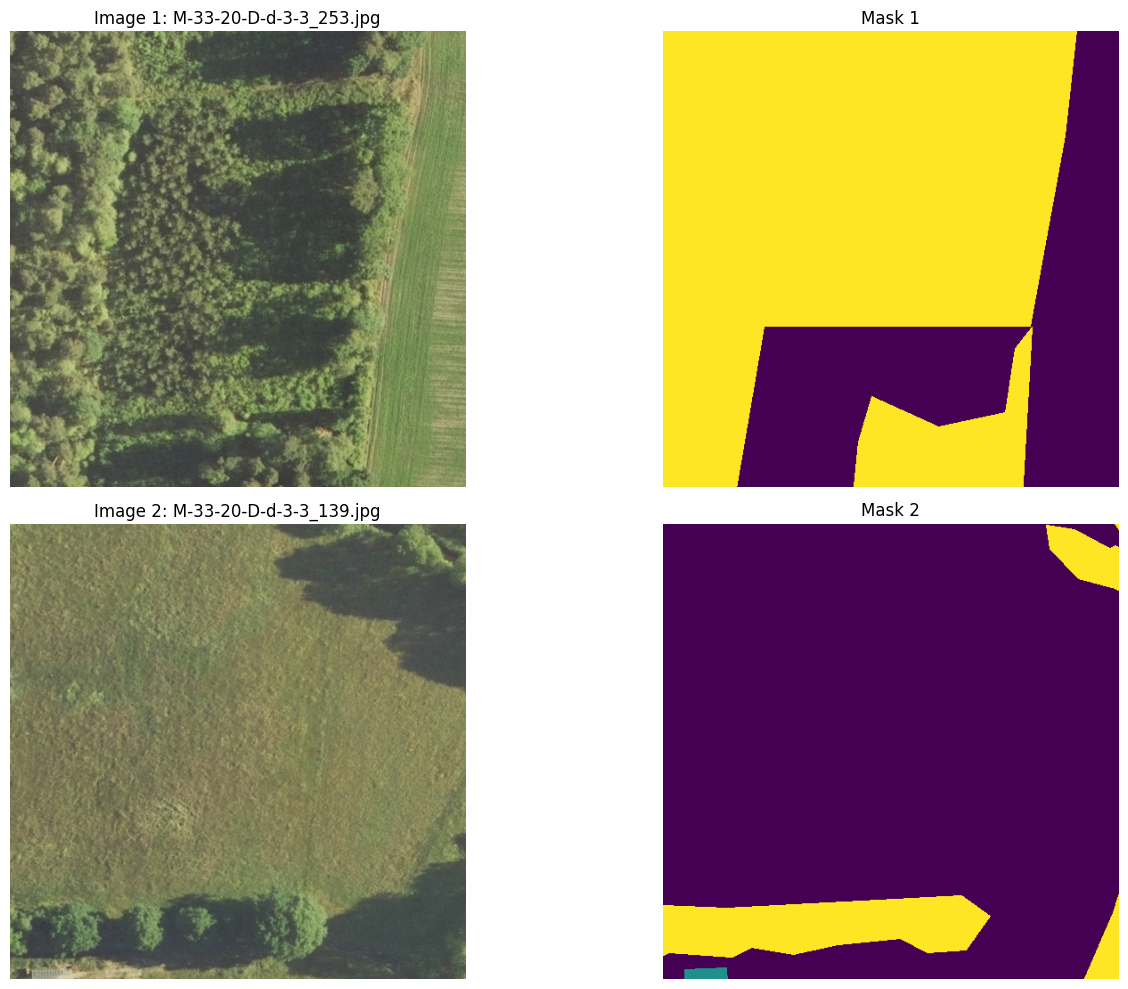

In [ ]:
displaySample(trainDF, 2)

Mask: 1: M-33-20-D-d-3-3_253_m.png
Unique Values: [0 2]
Class 0: background: 80636 pixels (30.76%)
Class 2: woodlands: 181508 pixels (69.24%)


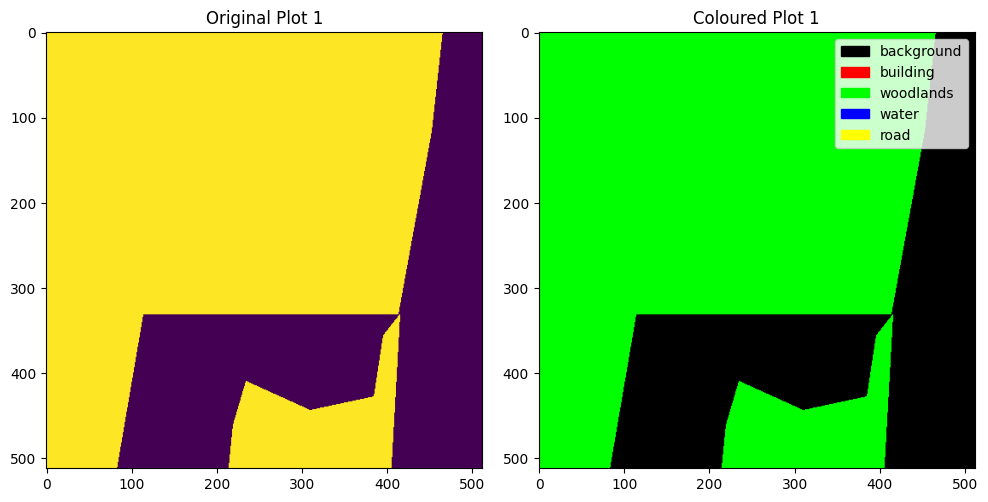


Mask: 2: M-33-20-D-d-3-3_139_m.png
Unique Values: [0 1 2]
Class 0: background: 237203 pixels (90.49%)
Class 1: building: 580 pixels (0.22%)
Class 2: woodlands: 24361 pixels (9.29%)


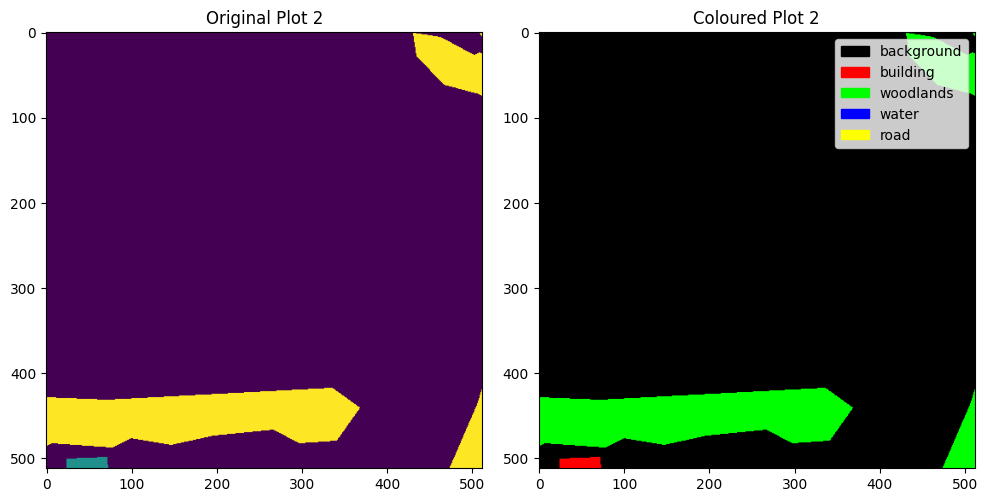


Mask: 3: M-33-20-D-d-3-3_154_m.png
Unique Values: [0 1 2 4]
Class 0: background: 206704 pixels (78.85%)
Class 1: building: 7533 pixels (2.87%)
Class 2: woodlands: 44490 pixels (16.97%)
Class 4: road: 3417 pixels (1.30%)


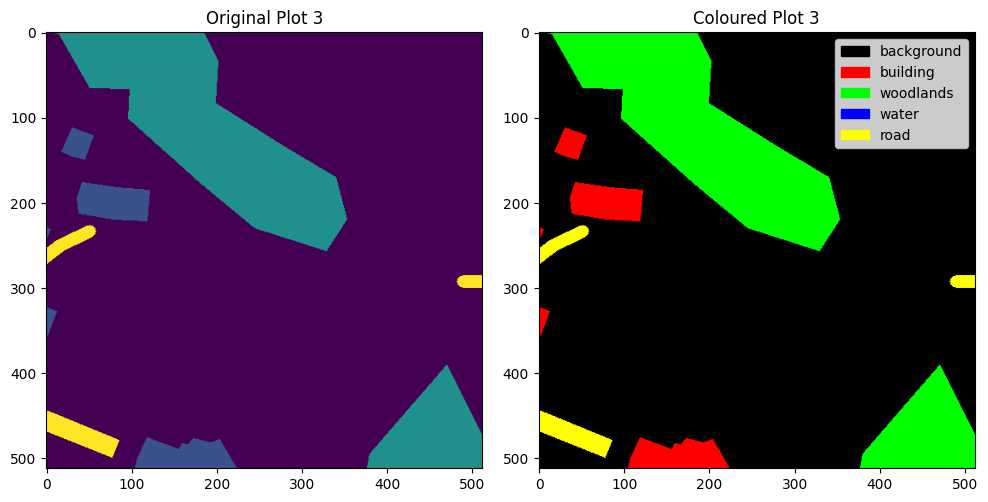


All unique values found across 3 masks: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(4)]


In [ ]:
def explore_mask_values(df, num_samples=5):

    class_names = ["background", "building", "woodlands", "water", "road"]
    class_colours = [(0,0,0), (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]

    unique_val = set()

    for i in range(min(num_samples, len(df))):
        mask_path = df['mask'].iloc[i]

        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            if mask is not None:
                mask_channel = mask[:,:,0] #only need one channel
                values = np.unique(mask_channel)
                unique_val.update(values)

                print(f"Mask: {i+1}: {os.path.basename(mask_path)}")
                print(f"Unique Values: {values}")

                for val in values:
                    if val < len(class_names):
                        class_name = class_names[val]
                        count = np.sum(mask_channel == val)
                        percentage = (count / mask_channel.size)*100
                        print(f"Class {val}: {(class_name)}: {count} pixels ({percentage:.2f}%)")

                plt.figure(figsize=(10,10))

                # original mask
                plt.subplot(1,2,1)
                plt.title(f"Original Plot {i+1}")
                plt.imshow(mask_channel)

                # coloured mask
                plt.subplot(1,2,2)
                plt.title(f"Coloured Plot {i+1}")

                h,w = mask_channel.shape
                rgb_mask = np.zeros((h,w,3), dtype=np.uint8)

                for class_id, colour in enumerate(class_colours):
                    if (class_id < len(class_colours)):
                        rgb_mask[mask_channel == class_id] = colour
                plt.imshow(rgb_mask)

                #legends
                legends = [plt.Rectangle((0,0), 1, 1, color = np.array(color)/255) for color in class_colours]
                plt.legend(legends, class_names, loc="upper right")

                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"Error processing mask {mask_path}: {str(e)}")
        print()
    print(f"All unique values found across {num_samples} masks: {sorted(unique_val)}")

explore_mask_values(trainDF, 3)


## Data Loading

In [ ]:
class MultiClassSegDataset(Dataset):
    def __init__(self, df, transformations):
        valid_rows = []
        for i, row in df.iterrows():
            if os.path.exists(row['img']) and os.path.exists(row['mask']):
                valid_rows.append(i)

        self.df = df.iloc[valid_rows].reset_index(drop=True)
        print(f"Found {len(self.df)} valid image-mask pairs out of {len(df)} pairs")

        self.transform = transformations
        self.num_classes = len(CLASSES) # Store the number of classes

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx, 1]
        mask_name = self.df.iloc[idx, 2]

        image = cv2.imread(image_name)
        if image is None:
            raise ValueError(f"Failed to load {os.path.basename(image_name)}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_name, cv2.IMREAD_UNCHANGED)
        if mask is None:
            raise ValueError(f"Failed to load {os.path.basename(mask_name)}")

        image = image.astype('uint8')
        mask = mask[:,:,0]

        # Ensure mask values are within the valid range [0, num_classes - 1]
        if np.max(mask) >= self.num_classes or np.min(mask) < 0:
            print(f"Warning: Mask {os.path.basename(mask_name)} contains out-of-range values. Max: {np.max(mask)}, Min: {np.min(mask)}. Clipping to [0, {self.num_classes-1}]")
            mask = np.clip(mask, 0, self.num_classes - 1)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)

        #changing format
        image = image.permute(2,0,1) # Corrected typo: iamge -> image
        image = image.float() / 255

        mask = mask.long()

        return image, mask

    def __len__(self):
        return len(self.df)


In [ ]:
import albumentations as A

test_transforms = A.Compose([
    A.PadIfNeeded(min_height=512, min_width=512, border_mode=4),
    A.Resize(512,512),
])

train_transforms = A.Compose([
    A.PadIfNeeded(min_height=512, min_width=512, border_mode=4),
    A.Resize(512, 512),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.MedianBlur(blur_limit=3, p=0.1),
])

#Initialise datasets
trainDS = MultiClassSegDataset(trainDF, train_transforms)
valDS = MultiClassSegDataset(valDF, test_transforms)
testDS = MultiClassSegDataset(testDF, test_transforms)

print(f"Final Training Samples: {len(trainDS)}")
print(f"Final Validation Samples: {len(valDS)}")
print(f"Final Testing Samples: {len(testDS)}")

trainDL = DataLoader(trainDS, batch_size=8, shuffle=True, num_workers=0,    pin_memory=False, drop_last=True)
valDL = DataLoader(valDS, batch_size=8, shuffle=False, num_workers=0, pin_memory=False, drop_last=True)
testDL = DataLoader(testDS, batch_size=8, shuffle=False, num_workers=0, pin_memory=False, drop_last=True)


Found 428 valid image-mask pairs out of 428 pairs
Found 91 valid image-mask pairs out of 91 pairs
Found 93 valid image-mask pairs out of 93 pairs
Final Training Samples: 428
Final Validation Samples: 91
Final Testing Samples: 93


## UNET Implementation

In [ ]:
class DoubleConv2d(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.layers(x)


In [ ]:
class UNET(nn.Module):
  def __init__(self, in_channels=3, out_channels=5, features=[16,32,64,128]):
    super().__init__()

    self.ups = nn.ModuleList()
    self.downs = nn.ModuleList()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    #down stuff
    for feature in features:
      self.downs.append(DoubleConv2d(in_channels, feature))
      in_channels = feature

    #up stuff
    for feature in reversed(features):
      self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
      self.ups.append(DoubleConv2d(feature*2, feature))

    self.bottleneck = DoubleConv2d(features[-1], features[-1] * 2)
    self.final_conv = nn.Conv2d(in_channels=features[0], out_channels=out_channels, kernel_size=1)

  def forward(self, x):
      skip_connections = []

      for down in self.downs:
        x = down(x)
        skip_connections.append(x)
        x = self.pool(x)

      x = self.bottleneck(x)
      skip_connections.reverse()

      for ind in range(0, len(self.ups), 2):
        x = self.ups[ind](x)
        skip_connection = skip_connections[ind//2]

        #check shape of skip connection and x
        if x.shape != skip_connection.shape:
          x = tf.resize(x, size=skip_connection.shape[2:])

        concat_x = torch.cat((skip_connection, x), dim=1)
        x = self.ups[ind+1](concat_x)

      return self.final_conv(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [ ]:
model = UNET(
    in_channels=3,
    out_channels=len(CLASSES),
    features=[32,64,128, 256]
).to(device)

## Training

In [ ]:
n_epochs = 30
save_folder = "/content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/checkpoints"
os.makedirs(save_folder, exist_ok=True)

In [ ]:
# generating class counts

# class_counts = torch.zeros(len(CLASSES))

# for mask_path in mask_paths:
#     mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
#     mask = torch.from_numpy(mask).view(-1)

#     bincount = torch.bincount(mask, minlength=len(CLASSES) )
#     class_counts += bincount

# print(class_counts)

# N = class_counts.sum()
# C = len(class_counts)

# class_counts[class_counts == 0] = 1
# ce_weights = N / (C * class_counts)
# ce_weights = ce_weights / ce_weights.sum() * C
# ce_weights = ce_weights.to(device)

# torch.save(ce_weights, os.path.join(save_folder, "entropy_loss_weights.pt"))


In [ ]:
class HybridLoss(nn.Module):
    def __init__(self, dice_weight, weights):
        super().__init__()
        self.dice = losses.DiceLoss(average="macro")
        weights = torch.load(os.path.join(save_folder, "entropy_loss_weights.pt")).to(device)
        self.en = nn.CrossEntropyLoss(weight=weights)
        self.dice_w = dice_weight
        self.en_w = 1 - dice_weight

    def forward(self, preds, target):
        return self.dice_w * self.dice(preds, target) + self.en_w * self.en(preds, target)

In [ ]:
ce_weights = torch.load(os.path.join(save_folder, "entropy_loss_weights.pt"), map_location=torch.device(device))

dice_weight = 1.0
criterion = HybridLoss(dice_weight, ce_weights)
optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3)
max_lr = 5e-4

total_steps = n_epochs * len(trainDL) + 100
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser,
    max_lr=max_lr,
    three_phase=True,
    total_steps = total_steps,
)

acc = tm.Accuracy(task="multiclass", num_classes=5, average="micro").to(device)
f1 = tm.F1Score(task="multiclass", num_classes=5, average="macro").to(device)
kappa = tm.CohenKappa(task="multiclass", num_classes=5).to(device)
#for smaller masks

#list of metrics
epNum = []
t_loss = []
t_acc = []
t_f1 = []
t_kappa = []
v_loss = []
v_acc = []
v_f1 = []
v_kappa = []

#best validation f1 score
f1_max_v = 0.0

print("Setup complete for training!")
print(f"Training for {n_epochs} epochs")
print(f"Model checkpoints will be saved to: {save_folder}")
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimiser.__class__.__name__}")
print(f"Learning rate scheduler: {scheduler.__class__.__name__}")

Setup complete for training!
Training for 30 epochs
Model checkpoints will be saved to: /content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/checkpoints
Loss function: HybridLoss
Optimizer: AdamW
Learning rate scheduler: OneCycleLR


In [ ]:
if device.type == "cuda":
    print(f"Starting training for {n_epochs} epochs....")

    for epoch in range(1, n_epochs+1):

        running_loss = 0.0
        model.train()

        for batch_id, (X, y) in enumerate(trainDL):

            X, y = X.to(device), y.to(device)
            optimiser.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)

            acc.update(y_pred, y)
            f1.update(y_pred, y)
            kappa.update(y_pred, y)

            loss.backward()
            optimiser.step()
            scheduler.step()

            running_loss += loss.item()

            # if(batch_id + 1)%5 == 0:
            #     print(f"Epoch: {epoch}, Batch: {batch_id+1} / {len(trainDL)}, Loss: {loss:.4f}")

        epoch_loss = running_loss / len(trainDL)
        acc_train = acc.compute()
        f1_train = f1.compute()
        kappa_train = kappa.compute()

        curr_lr = scheduler.get_last_lr()[0]

        print(f'Epoch: {epoch}')
        print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {acc_train:.4f}, Training F1: {f1_train:.4f}, Training Kappa: {kappa_train:.6f}, LR: {curr_lr:.6f}")

        epNum.append(epoch)
        t_loss.append(epoch_loss)
        t_acc.append(acc_train.detach().cpu().numpy())
        t_f1.append(f1_train.detach().cpu().numpy())
        t_kappa.append(kappa_train.detach().cpu().numpy())

        acc.reset()
        f1.reset()
        kappa.reset()

        #validation set
        model.eval()

        with torch.no_grad():
            running_loss_v = 0.0
            for batch_id, (X, y) in enumerate(valDL):

                X, y = X.to(device), y.to(device)
                y_pred = model(X)
                loss_v = criterion(y_pred, y)

                acc.update(y_pred, y)
                f1.update(y_pred, y)
                kappa.update(y_pred, y)

                running_loss_v += loss_v.item()

        epoch_loss_v = running_loss_v / len(valDL)
        acc_val = acc.compute()
        f1_val = f1.compute()
        kappa_val = kappa.compute()

        print(f'Validation Loss: {epoch_loss_v:.4f}, Validation Accuracy: {acc_val:.4f}, Validation F1: {f1_val:.4f}, Validation Kappa: {kappa_val:.6f}\n')

        v_loss.append(epoch_loss_v)
        v_acc.append(acc_val.detach().cpu().numpy())
        v_f1.append(f1_val.detach().cpu().numpy())
        v_kappa.append(kappa_val.detach().cpu().numpy())

        acc.reset()
        f1.reset()
        kappa.reset()

        #saving model
        f1_val_np = f1_val.detach().cpu().numpy()
        if f1_val_np > f1_max_v:
            f1_max_v = f1_val_np
            torch.save(model.state_dict(), os.path.join(save_folder, 'GS_Seg_UNET_model.pt'))
            print(f"Model saved for epoch {epoch}\n")

    results_df = pd.DataFrame({
        "epoch": epNum,
        "training_loss": t_loss,
        "training_accuracy": t_acc,
        "training_f1": t_f1,
        "training_kappa": t_kappa,
        "val_loss": v_loss,
        "val_accuracy": v_acc,
        "val_f1": v_f1,
        "val_kappa": v_kappa
    })

    results_path = os.path.join(save_folder, f"training_results_{n_epochs}_{f1_max_v:.6f}_f{max_lr}.csv")
    results_df.to_csv(os.path.join(save_folder, results_path), index=False)
    print(f"Training completed. Results saved to {os.path.join(save_folder, results_path)}")

In [ ]:
curr_model_path =  f'GS_Seg_UNET_model_{n_epochs}epochs_{max_lr}maxlr_{f1_max_v:.4f}f1valid.pt'

torch.save(model.state_dict(), os.path.join(save_folder, curr_model_path))

## Graphs

In [ ]:
os.listdir(save_folder)

['entropy_loss_weights.csv',
 'GS_Seg_UNET_model_30epochs_0.0005maxlr_0.7915539741516113f1valid.pt',
 'training_results_79f1.csv',
 'training_results_60_0.7551.csv',
 'GS_Seg_UNET_model.pt',
 'GS_Seg_UNET_model_60epochs_0.0005maxlr_0.0000f1valid.pt',
 'entropy_loss_weights.pt',
 'GS_Seg_UNET_model_30epochs_0.0005maxlr_0.0000f1valid.pt']

30

Best model was saved at epoch 30.0 with Validation F1 of 0.7916


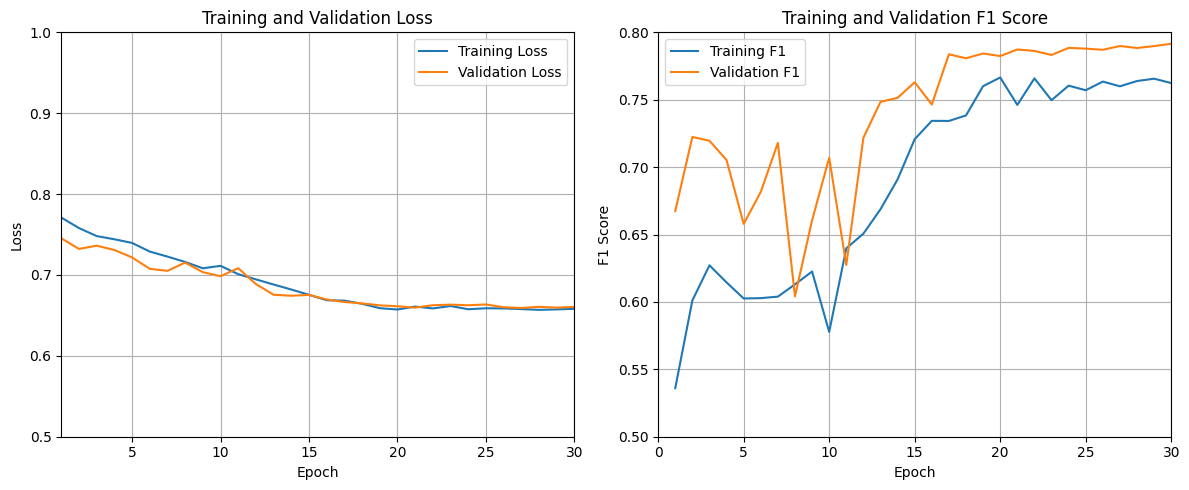

Saved figure to loss_curve_30epoch_0.0005maxlr_0.791554best_f1.png


In [ ]:
result_to_graph_path = 'training_results_79f1.csv'
results_df = pd.read_csv(os.path.join(save_folder, result_to_graph_path))
max_lr = 5e-4

tokens = result_to_graph_path.split('_')
# result_epochs = int(tokens[2])
print(result_epochs)

result_epochs = 30

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(results_df['epoch'], results_df['training_loss'], label="Training Loss")
plt.plot(results_df['epoch'], results_df['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.axis([1,result_epochs,0.5,1.0])
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(results_df['epoch'], results_df['training_f1'], label='Training F1')
plt.plot(results_df['epoch'], results_df['val_f1'], label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Training and Validation F1 Score')
plt.axis([0,result_epochs,0.5,0.8])
plt.legend()
plt.grid(True)

best_epoch = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nBest model was saved at epoch {best_epoch['epoch']} with Validation F1 of {best_epoch['val_f1']:.4f}")

plt.tight_layout()
namefig = f"loss_curve_{result_epochs}epoch_{max_lr}maxlr_{best_epoch['val_f1']}best_f1.png"
plt.savefig(namefig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {namefig}")




## Testing

In [ ]:
# 1. Load the best saved model weights
curr_model_path = "GS_Seg_UNET_model_30epochs_0.0005maxlr_0.7915539741516113f1valid.pt"

best_model_path = os.path.join(save_folder, curr_model_path)
if os.path.exists(best_model_path):
    #fot cpu time inference
    model.load_state_dict(torch.load(best_model_path, map_location=torch.device(device)))
    # model.load_state_dict(torch.load(best_model_path))
    print(f"Successfully loaded best model from {best_model_path}")
else:
    raise ValueError("Model Weights cannot be found")

Successfully loaded best model from /content/drive/MyDrive/Colab Notebooks/GS_Segmentation_UNET/checkpoints/GS_Seg_UNET_model_30epochs_0.0005maxlr_0.7915539741516113f1valid.pt


In [ ]:
model.eval()

# Metrics for testing (using the same logic as your training loop)
test_acc = tm.Accuracy(task="multiclass", num_classes=5, average="micro").to(device)
test_f1 = tm.F1Score(task="multiclass", num_classes=5, average="macro").to(device)
test_kappa = tm.CohenKappa(task="multiclass", num_classes=5).to(device)

running_loss_test = 0.0

with torch.no_grad():
    for X_test, y_test in testDL:
        X_test, y_test = X_test.to(device), y_test.to(device)

        y_pred = model(X_test)
        loss_t = criterion(y_pred, y_test)

        # Update metrics
        test_acc.update(y_pred, y_test)
        test_f1.update(y_pred, y_test)
        test_kappa.update(y_pred, y_test)

        running_loss_test += loss_t.item()

        predicted_mask = y_pred
        gt = y_test

# Compute final results
final_test_loss = running_loss_test / len(testDL)
final_test_acc = test_acc.compute()
final_test_f1 = test_f1.compute()
final_test_kappa = test_kappa.compute()

print(f"--- Final Test Results ---")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.4f}")
print(f"Test F1-Score: {final_test_f1:.4f}")
print(f"Test Cohen's Kappa: {final_test_kappa:.4f}")

# Reset metrics after computation
test_acc.reset()
test_f1.reset()
test_kappa.reset()

--- Final Test Results ---
Test Loss: 0.6559
Test Accuracy: 0.9117
Test F1-Score: 0.8064
Test Cohen's Kappa: 0.8519


In [ ]:
def display_prediction(pred, gt):
    class_colours = np.array([
        (0, 0, 0),       # background
        (255, 0, 0),     # building
        (0, 255, 0),     # woodlands
        (0, 0, 255),     # water
        (255, 255, 0)    # road
    ], dtype=np.uint8)

    mask_p = torch.argmax(pred, dim=0).cpu().numpy()
    mask_t = gt.cpu().numpy()

    rgb_p = class_colours[mask_p]
    rgb_t = class_colours[mask_t]

    # 3. Visualization
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(rgb_p)
    ax[0].set_title("Prediction")
    ax[0].axis('off')

    ax[1].imshow(rgb_t)
    ax[1].set_title("Ground Truth")
    ax[1].axis('off')

    plt.show()


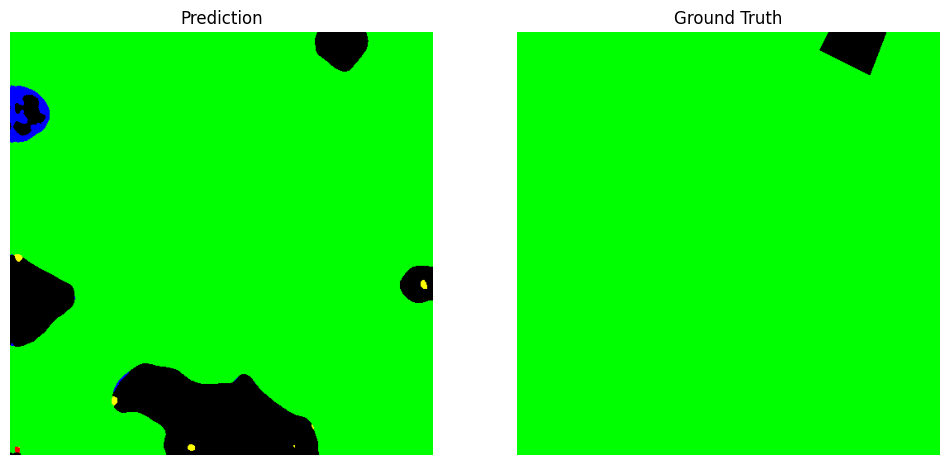

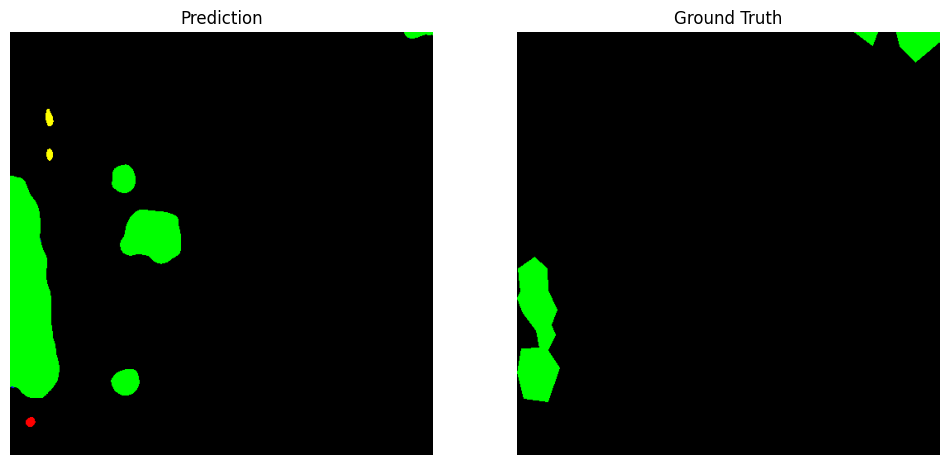

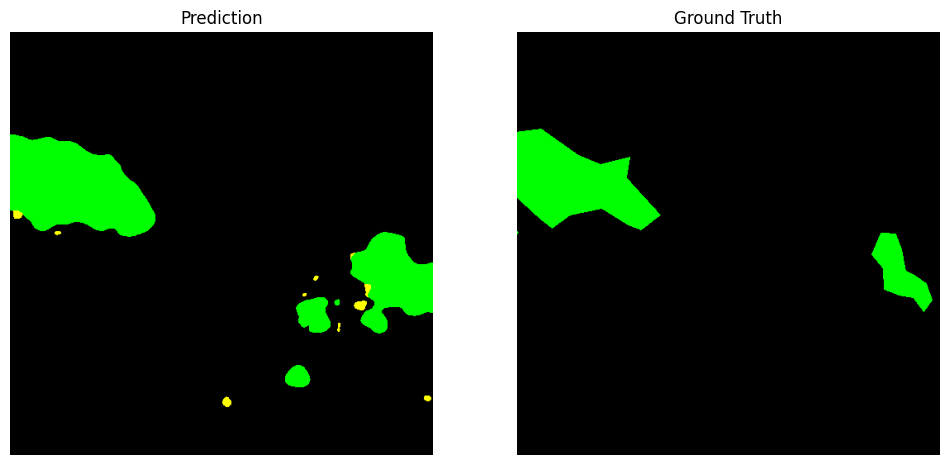

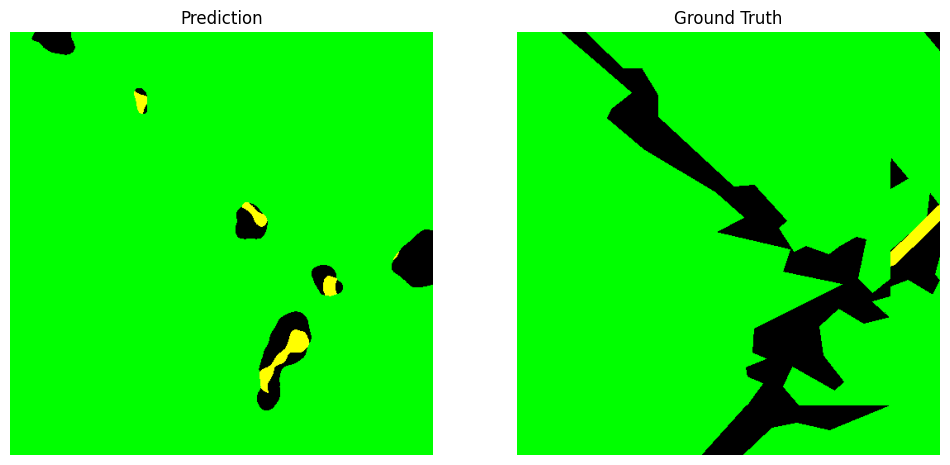

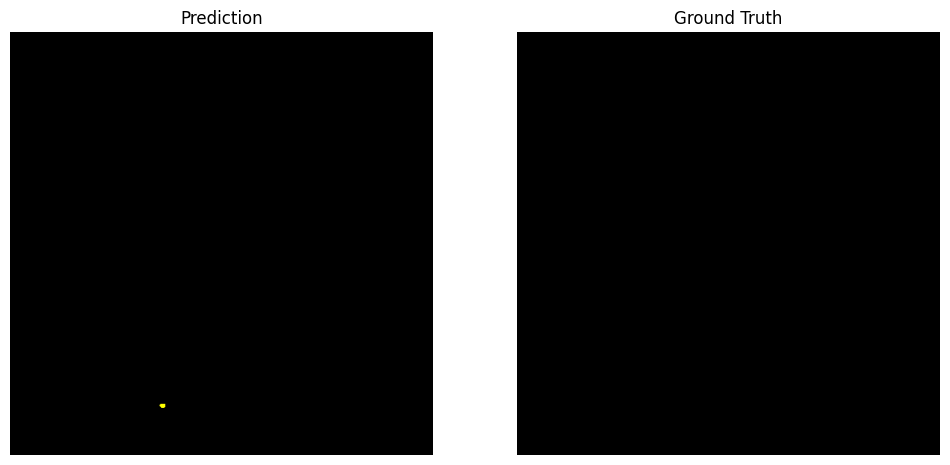

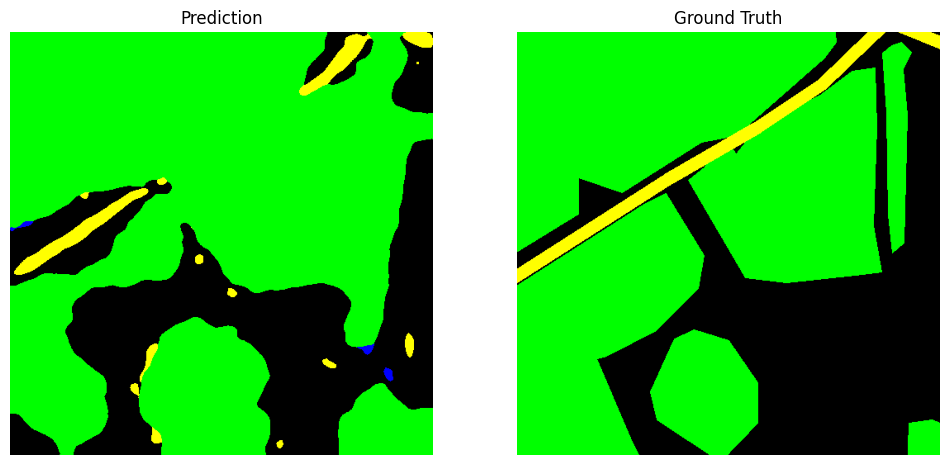

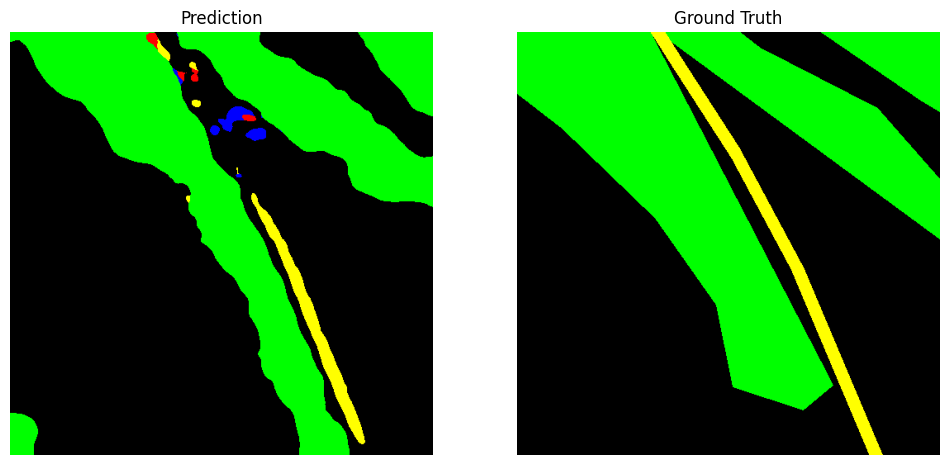

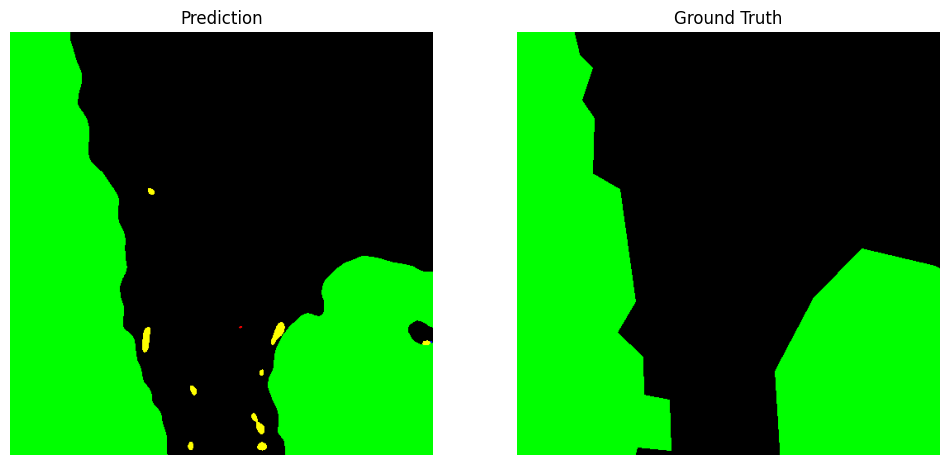

In [ ]:
for i in range(8):
    display_prediction(predicted_mask[i], gt[i])

In [ ]:
# from google.colab import runtime
# runtime.unassign()